In [1]:
# Install all required dependencies.
# torch is provided by the Colab GPU runtime; the pinned versions below are what
# bert-score needs to run correctly on current Colab.
!pip -q install pandas numpy matplotlib nltk "transformers==4.44.2" "bert-score==0.3.13" "tokenizers==0.19.1"
print('installed - if bert-score errors, use Runtime > Restart session once, then Run all')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
installed - if bert-score errors, use Runtime > Restart session once, then Run all


In [2]:
import time, math, random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from nltk.translate.bleu_score import corpus_bleu
from bert_score import score as bert_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


Upload files

In [3]:
try:
    from google.colab import files
    files.upload()
except Exception:
    pass

Saving dev_en_1000.csv to dev_en_1000.csv
Saving dev_sa_1000.csv to dev_sa_1000.csv
Saving test_en_1000.csv to test_en_1000.csv
Saving test_sa_1000.csv to test_sa_1000.csv
Saving train_en_10000.csv to train_en_10000.csv
Saving train_sa_10000.csv to train_sa_10000.csv


Load Data

In [4]:
DATA_DIR = '/content/'

def load(sa_file, en_file):
    sa = pd.read_csv(DATA_DIR + sa_file, encoding='utf-8-sig')
    en = pd.read_csv(DATA_DIR + en_file, encoding='utf-8-sig')
    sa.columns = [c.strip() for c in sa.columns]
    en.columns = [c.strip() for c in en.columns]
    df = sa.merge(en, on='Source_id').dropna(subset=['Sentence_sa', 'Sentence_en'])
    df = df.reset_index(drop=True)
    df['Sentence_sa'] = df['Sentence_sa'].astype(str).str.strip()
    df['Sentence_en'] = df['Sentence_en'].astype(str).str.strip()
    return df

def load_test(sa_file, en_file):
    # the private test set may come without english references - never drop rows for that
    sa = pd.read_csv(DATA_DIR + sa_file, encoding='utf-8-sig')
    sa.columns = [c.strip() for c in sa.columns]
    sa = sa.dropna(subset=['Sentence_sa']).reset_index(drop=True)
    sa['Sentence_sa'] = sa['Sentence_sa'].astype(str).str.strip()
    try:
        en = pd.read_csv(DATA_DIR + en_file, encoding='utf-8-sig')
        en.columns = [c.strip() for c in en.columns]
        df = sa.merge(en, on='Source_id', how='left')
    except FileNotFoundError:
        df = sa.copy()
        df['Sentence_en'] = ''
    df['Sentence_en'] = df['Sentence_en'].fillna('').astype(str).str.strip()
    return df

train_df = load('train_sa_10000.csv', 'train_en_10000.csv')
dev_df   = load('dev_sa_1000.csv',    'dev_en_1000.csv')
test_df  = load_test('test_sa_1000.csv', 'test_en_1000.csv')
print(len(train_df), len(dev_df), len(test_df))
train_df.head()


10000 1000 1000


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


tokenizers & vocab

In [5]:
def tok_sa(t):
    return list(t.strip())

def tok_en(t):
    return t.lower().strip().split()

PAD_IDX, UNK_IDX, SOS_IDX, EOS_IDX = 0, 1, 2, 3

class Vocab:
    def __init__(self, min_freq=1):
        self.min_freq = min_freq
        self.stoi = {'<pad>': 0, '<unk>': 1, '<sos>': 2, '<eos>': 3}
        self.itos = {i: t for t, i in self.stoi.items()}

    def build(self, sentences, tok):
        c = Counter()
        for s in sentences:
            c.update(tok(s))
        for w, f in c.items():
            if f >= self.min_freq and w not in self.stoi:
                i = len(self.stoi)
                self.stoi[w] = i
                self.itos[i] = w
        return self

    def encode(self, toks):
        return [self.stoi.get(t, UNK_IDX) for t in toks]

    def decode(self, ids):
        skip = {PAD_IDX, UNK_IDX, SOS_IDX, EOS_IDX}
        return [self.itos.get(i, '<unk>') for i in ids if i not in skip]

    def __len__(self):
        return len(self.stoi)

src_vocab = Vocab(min_freq=1).build(train_df['Sentence_sa'], tok_sa)
tgt_vocab = Vocab(min_freq=2).build(train_df['Sentence_en'], tok_en)   # drop rare english words
print('src', len(src_vocab), '| tgt', len(tgt_vocab))

src 194 | tgt 7072


dataset & dataloaders

In [6]:
MAX_SRC, MAX_TGT = 180, 60

class NMTData(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        src = src_vocab.encode(tok_sa(r['Sentence_sa'])[:MAX_SRC]) or [UNK_IDX]
        tgt = [SOS_IDX] + tgt_vocab.encode(tok_en(r['Sentence_en'])[:MAX_TGT]) + [EOS_IDX]
        return torch.tensor(src), torch.tensor(tgt)

def collate(batch):
    src, tgt = zip(*batch)
    src_len = torch.tensor([len(x) for x in src])
    src = nn.utils.rnn.pad_sequence(src, batch_first=True, padding_value=PAD_IDX)
    tgt = nn.utils.rnn.pad_sequence(tgt, batch_first=True, padding_value=PAD_IDX)
    return src, tgt, src_len

BATCH = 64
train_loader = DataLoader(NMTData(train_df), BATCH, shuffle=True,  collate_fn=collate)
dev_loader   = DataLoader(NMTData(dev_df),   BATCH, shuffle=False, collate_fn=collate)
print(len(train_loader), len(dev_loader))

157 16


model (encoder, attention, decoder, seq2seq)

In [7]:
class Encoder(nn.Module):
    def __init__(self, vocab, emb, enc_h, dec_h, dropout):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb, padding_idx=PAD_IDX)
        self.rnn = nn.GRU(emb, enc_h, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(enc_h * 2, dec_h)
        self.drop = nn.Dropout(dropout)

    def forward(self, src, src_len):
        e = self.drop(self.emb(src))
        packed = pack_padded_sequence(e, src_len.cpu(), batch_first=True, enforce_sorted=False)
        out, h = self.rnn(packed)
        out, _ = pad_packed_sequence(out, batch_first=True)
        h = torch.tanh(self.fc(torch.cat([h[-2], h[-1]], dim=1)))   # combine both directions
        return out, h

class Attention(nn.Module):
    def __init__(self, enc_h, dec_h):
        super().__init__()
        self.attn = nn.Linear(enc_h * 2 + dec_h, dec_h)
        self.v = nn.Linear(dec_h, 1, bias=False)

    def forward(self, hidden, enc_out, mask):
        S = enc_out.shape[1]
        h = hidden.unsqueeze(1).repeat(1, S, 1)
        e = torch.tanh(self.attn(torch.cat([h, enc_out], dim=2)))
        score = self.v(e).squeeze(2).masked_fill(mask == 0, -1e10)
        return F.softmax(score, dim=1)

class Decoder(nn.Module):
    def __init__(self, vocab, emb, enc_h, dec_h, dropout):
        super().__init__()
        self.vocab = vocab
        self.emb = nn.Embedding(vocab, emb, padding_idx=PAD_IDX)
        self.attn = Attention(enc_h, dec_h)
        self.rnn = nn.GRU(emb + enc_h * 2, dec_h, batch_first=True)
        self.fc = nn.Linear(dec_h + enc_h * 2 + emb, vocab)
        self.drop = nn.Dropout(dropout)

    def forward(self, tok, hidden, enc_out, mask):
        tok = tok.unsqueeze(1)
        e = self.drop(self.emb(tok))
        a = self.attn(hidden, enc_out, mask).unsqueeze(1)
        ctx = torch.bmm(a, enc_out)
        out, h = self.rnn(torch.cat([e, ctx], dim=2), hidden.unsqueeze(0))
        pred = self.fc(torch.cat([out.squeeze(1), ctx.squeeze(1), e.squeeze(1)], dim=1))
        return pred, h.squeeze(0)

class Seq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.enc = enc
        self.dec = dec

    def mask(self, src):
        return src != PAD_IDX

    def forward(self, src, src_len, tgt, tf_ratio=0.5):
        B, T = tgt.shape
        outputs = torch.zeros(B, T, self.dec.vocab, device=src.device)
        m = self.mask(src)
        enc_out, hidden = self.enc(src, src_len)
        inp = tgt[:, 0]
        for t in range(1, T):
            pred, hidden = self.dec(inp, hidden, enc_out, m)
            outputs[:, t] = pred
            inp = tgt[:, t] if random.random() < tf_ratio else pred.argmax(1)
        return outputs

build the model

In [8]:
EMB, ENC_H, DEC_H, DROP = 128, 256, 256, 0.3
LR, EPOCHS, CLIP = 3e-4, 15, 1.0

enc = Encoder(len(src_vocab), EMB, ENC_H, DEC_H, DROP)
dec = Decoder(len(tgt_vocab), EMB, ENC_H, DEC_H, DROP)
model = Seq2Seq(enc, dec).to(device)

for _, p in model.named_parameters():
    nn.init.uniform_(p.data, -0.08, 0.08)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('parameters:', f'{n_params:,}')

parameters: 8,884,640


Train

In [9]:
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

def run(loader, train):
    model.train() if train else model.eval()
    total = 0.0
    tf = 0.5 if train else 0.0
    with torch.set_grad_enabled(train):
        for src, tgt, src_len in loader:
            src, tgt = src.to(device), tgt.to(device)
            if train:
                optimizer.zero_grad()
            out = model(src, src_len, tgt, tf)
            V = out.shape[-1]
            loss = criterion(out[:, 1:].reshape(-1, V), tgt[:, 1:].reshape(-1))
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CLIP)
                optimizer.step()
            total += loss.item()
    return total / len(loader)

best = float('inf')
train_hist, dev_hist = [], []
for ep in range(1, EPOCHS + 1):
    t0 = time.time()
    tr = run(train_loader, True)
    dv = run(dev_loader, False)
    scheduler.step(dv)
    train_hist.append(tr)
    dev_hist.append(dv)
    if dv < best:
        best = dv
        torch.save(model.state_dict(), 'best_model.pt')
    print(f'epoch {ep:02d}  train {tr:.3f}  dev {dv:.3f}  ppl {math.exp(dv):.1f}  {time.time()-t0:.0f}s')

epoch 01  train 6.810  dev 6.226  ppl 505.9  52s
epoch 02  train 6.408  dev 6.121  ppl 455.5  54s
epoch 03  train 6.257  dev 6.000  ppl 403.4  53s
epoch 04  train 6.092  dev 5.948  ppl 382.9  53s
epoch 05  train 5.987  dev 5.924  ppl 374.0  53s
epoch 06  train 5.882  dev 5.919  ppl 372.0  53s
epoch 07  train 5.797  dev 5.872  ppl 355.1  54s
epoch 08  train 5.720  dev 5.873  ppl 355.5  53s
epoch 09  train 5.657  dev 5.831  ppl 340.6  53s
epoch 10  train 5.596  dev 5.835  ppl 342.2  54s
epoch 11  train 5.538  dev 5.810  ppl 333.7  54s
epoch 12  train 5.481  dev 5.792  ppl 327.8  54s
epoch 13  train 5.392  dev 5.809  ppl 333.2  54s
epoch 14  train 5.345  dev 5.798  ppl 329.5  54s
epoch 15  train 5.297  dev 5.779  ppl 323.6  54s


training curves

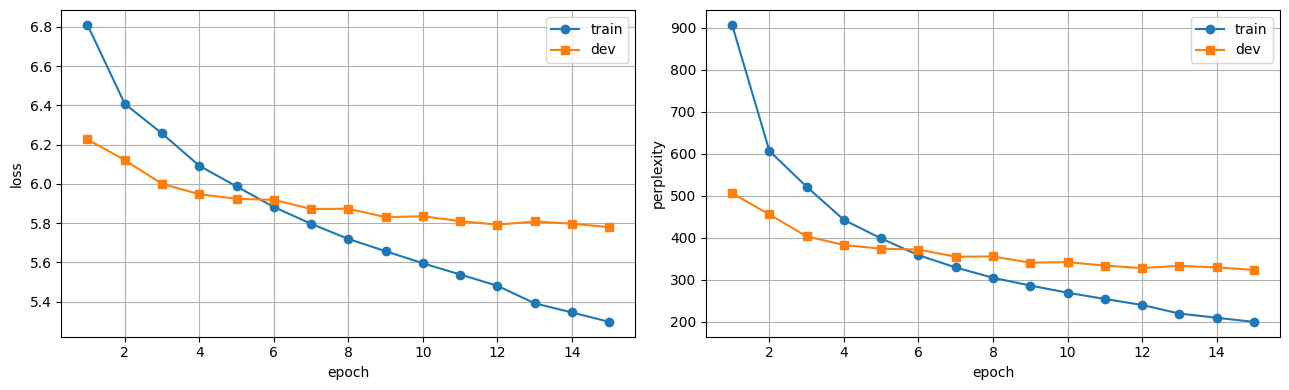

In [10]:
x = range(1, len(train_hist) + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(x, train_hist, 'o-', label='train'); ax[0].plot(x, dev_hist, 's-', label='dev')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss'); ax[0].legend(); ax[0].grid(True)
ax[1].plot(x, [math.exp(l) for l in train_hist], 'o-', label='train')
ax[1].plot(x, [math.exp(l) for l in dev_hist], 's-', label='dev')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('perplexity'); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.savefig('training_curves.png', dpi=150); plt.show()

beam search decoder

In [11]:
import re

def beam_search(src_ids, beam=5, max_len=MAX_TGT, alpha=0.7, no_repeat=3):
    model.eval()
    with torch.no_grad():
        src = torch.tensor([src_ids], device=device)
        src_len = torch.tensor([len(src_ids)])
        mask = model.mask(src)
        enc_out, hidden = model.enc(src, src_len)
        beams = [(0.0, [SOS_IDX], hidden)]
        done = []
        for step in range(max_len):
            cand = []
            for score, seq, h in beams:
                if seq[-1] == EOS_IDX:
                    done.append((score, seq)); continue
                inp = torch.tensor([seq[-1]], device=device)
                pred, h2 = model.dec(inp, h, enc_out, mask)
                logp = F.log_softmax(pred, dim=-1).squeeze(0)
                logp[PAD_IDX] = logp[UNK_IDX] = logp[SOS_IDX] = -1e9   # never emit these
                if len(seq) == 1:
                    logp[EOS_IDX] = -1e9                               # force at least one word
                if no_repeat > 0 and len(seq) >= no_repeat - 1:
                    # ban any token that would recreate an n-gram already in the hypothesis
                    prefix = seq[len(seq) - (no_repeat - 1):] if no_repeat > 1 else []
                    for k in range(len(seq) - no_repeat + 1):
                        if seq[k:k + no_repeat - 1] == prefix:
                            logp[seq[k + no_repeat - 1]] = -1e9
                lp, ix = logp.topk(beam)
                for a, b in zip(lp.tolist(), ix.tolist()):
                    cand.append((score + a, seq + [b], h2))
            if not cand:
                break
            cand.sort(key=lambda z: z[0] / (len(z[1]) ** alpha), reverse=True)   # length penalty
            beams = cand[:beam]
        done += [(s, seq) for s, seq, _ in beams]
        best = max(done, key=lambda z: z[0] / (len(z[1]) ** alpha))
        return ' '.join(tgt_vocab.decode(best[1]))

def truecase(text, src_text=''):
    words = text.split()
    if not words:
        return text
    # code-switched tokens (Ctrl, awk, Linux...) keep the casing they have in the source
    cased = {w.lower(): w for w in str(src_text).split() if any(c.isupper() for c in w)}
    words = [cased.get(w, w) for w in words]
    out = ' '.join(words)
    out = out[0].upper() + out[1:]
    out = re.sub(r'\bi\b', 'I', out)
    out = re.sub(r'([.!?]\s+)([a-z])', lambda m: m.group(1) + m.group(2).upper(), out)
    return out

def translate(df, beam=5, no_repeat=3):
    out = []
    for i in range(len(df)):
        row = df.iloc[i]
        ids = src_vocab.encode(tok_sa(row['Sentence_sa'])[:MAX_SRC]) or [UNK_IDX]
        hyp = beam_search(ids, beam, no_repeat=no_repeat)
        out.append(truecase(hyp, row['Sentence_sa']))
    return out


dev predictions + BLEU

In [12]:
model.load_state_dict(torch.load('best_model.pt', map_location=device))

def dev_bleu(pred):
    refs = [[r.lower().split()] for r in dev_df['Sentence_en']]
    hyps = [h.lower().split() for h in pred]
    return corpus_bleu(refs, hyps)   # default nltk bleu, no weights

# small sweep on dev: beam width x no-repeat n-gram size (0 = old behaviour)
results = {}
for b, nr in [(5, 0), (3, 3), (5, 3), (5, 2)]:
    p = translate(dev_df, beam=b, no_repeat=nr)
    results[(b, nr)] = (dev_bleu(p), p)
    print(f'beam={b} no_repeat={nr}  dev BLEU: {results[(b, nr)][0]:.4f}')

BEST_BEAM, BEST_NR = max(results, key=lambda k: results[k][0])
dev_pred = results[(BEST_BEAM, BEST_NR)][1]
print('selected: beam', BEST_BEAM, '| no_repeat', BEST_NR,
      '| dev BLEU', f'{results[(BEST_BEAM, BEST_NR)][0]:.4f}')


beam=5 no_repeat=0  dev BLEU: 0.0300
beam=3 no_repeat=3  dev BLEU: 0.0287
beam=5 no_repeat=3  dev BLEU: 0.0301
beam=5 no_repeat=2  dev BLEU: 0.0310
selected: beam 5 | no_repeat 2 | dev BLEU 0.0310


 dev BERTScore

In [13]:
_, _, F1 = bert_score(dev_pred, dev_df['Sentence_en'].tolist(), lang='en',
                      rescale_with_baseline=True, use_fast_tokenizer=True)
print('dev BERTScore F1:', round(F1.mean().item(), 4))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


dev BERTScore F1: 0.1029


 test predictions + submission.csv

In [14]:
t0 = time.time()
test_pred = translate(test_df, beam=BEST_BEAM, no_repeat=BEST_NR)
test_time = time.time() - t0

if test_df['Sentence_en'].notna().any() and (test_df['Sentence_en'].str.len() > 0).any():
    refs = [[r.lower().split()] for r in test_df['Sentence_en']]
    hyps = [h.lower().split() for h in test_pred]
    print('test BLEU:', round(corpus_bleu(refs, hyps), 4))
    _, _, F1 = bert_score(test_pred, test_df['Sentence_en'].tolist(), lang='en',
                          rescale_with_baseline=True, use_fast_tokenizer=True)
    print('test BERTScore F1:', round(F1.mean().item(), 4))

submission = pd.DataFrame({'Source_id': test_df['Source_id'].values, 'Sentence_en': test_pred})
submission.to_csv('submission.csv', index=False, encoding='utf-8')
print('submission.csv:', len(submission), 'rows')
submission.head()


test BLEU: 0.0309


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


test BERTScore F1: 0.1
submission.csv: 1000 rows


,Source_id,Sentence_en
0,1,It is the to the spoken tutorial on the
1,2,"""for we have to the the of the that we should ..."
2,3,"So, I can see that I have to the and I will se..."
3,4,"To record this tutorial, we have learnt about:..."
4,5,"""and when he that ye have to the that he is no..."


efficiency (params + test inference time)

In [15]:
print('total parameters       :', f'{n_params:,}')
print('test inference time (s) :', round(test_time, 2), f'for {len(test_df)} sentences')
print('per sentence (ms)       :', round(test_time / len(test_df) * 1000, 1))

total parameters       : 8,884,640
test inference time (s) : 216.44 for 1000 sentences
per sentence (ms)       : 216.4


 example translations

In [16]:
for i in range(8):
    print('SA  :', dev_df.iloc[i]['Sentence_sa'])
    print('REF :', dev_df.iloc[i]['Sentence_en'])
    print('PRED:', dev_pred[i])
    print()

SA  : ते वीराः ।
REF : Those are brave men.
PRED: Those two are

SA  : 'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां कारयति ।
REF : Infinite loop  can cause the system to become unresponsive.
PRED: There is the to the

SA  : ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर आजघ्नुः।
REF : "And they spit upon him, and took the reed, and smote him on the head."
PRED: "and when he that they had to the the of the

SA  : एते तिथी ।
REF : These two are dates.
PRED: These two are

SA  : "बहुविचारेषु जातषु पितर उत्थाय कथितवान्, हे भ्रातरो यथा भिन्नदेशीयलोका मम मुखात् सुसंवादं श्रुत्वा विश्वसन्ति तदर्थं बहुदिनात् पूर्व्वम् ईश्वरोस्माकं मध्ये मां वृत्वा नियुक्तवान्।"
REF : "And when there had been much disputing, Peter rose up, and said unto them, Men and brethren, ye know how that a good while ago God made choice among us, that the Gentiles by my mouth should hear the word of the gospel, and believe."
PRED: "and when he said unto them, and the the of the and he that they might be unto him, and that

In [17]:
try:
    from google.colab import files
    files.download('submission.csv')
    files.download('training_curves.png')
except Exception:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>